In [ ]:
# Linear Regression Analysis: Hours Studied vs Test Scores

This notebook demonstrates a simple linear regression analysis examining the relationship between hours studied and test scores.

2

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
# Create sample data: Hours studied vs Test scores
hours_studied = np.array([2, 4, 6, 8])
test_scores = np.array([65, 75, 85, 95])

# Create DataFrame for easier handling
data = pd.DataFrame({
    'Hours_Studied': hours_studied,
    'Test_Score': test_scores
})

print("Sample Data:")
print(data)
print(f"\nData shape: {data.shape}")
print(f"Sample size: {len(data)}")

Sample Data:
   Hours_Studied  Test_Score
0              2          65
1              4          75
2              6          85
3              8          95

Data shape: (4, 2)
Sample size: 4


In [3]:
# Perform linear regression using scipy.stats
slope, intercept, r_value, p_value, std_err = stats.linregress(hours_studied, test_scores)

# Calculate additional statistics
r_squared = r_value ** 2
n = len(hours_studied)
degrees_freedom = n - 2

# Calculate residuals and other statistics
predicted_scores = slope * hours_studied + intercept
residuals = test_scores - predicted_scores
mse = np.mean(residuals ** 2)
rmse = np.sqrt(mse)

print("=== LINEAR REGRESSION STATISTICAL SUMMARY ===")
print(f"Sample Size (n): {n}")
print(f"Degrees of Freedom: {degrees_freedom}")
print("\n--- Regression Equation ---")
print(f"y = {slope:.3f}x + {intercept:.3f}")
print(f"Test Score = {slope:.3f} × Hours Studied + {intercept:.3f}")

print("\n--- Key Statistics ---")
print(f"Correlation Coefficient (r): {r_value:.4f}")
print(f"R-squared (r²): {r_squared:.4f}")
print(f"Adjusted R-squared: {1 - (1 - r_squared) * (n - 1) / degrees_freedom:.4f}")
print(f"Standard Error of Estimate: {std_err:.4f}")
print(f"P-value: {p_value:.6f}")

print("\n--- Model Performance ---")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

print("\n--- Interpretation ---")
print(f"• {r_squared*100:.1f}% of the variance in test scores is explained by hours studied")
print(f"• For each additional hour studied, test score increases by {slope:.1f} points")
print(f"• The correlation is {'very strong' if r_squared > 0.8 else 'strong' if r_squared > 0.6 else 'moderate' if r_squared > 0.4 else 'weak'}")

=== LINEAR REGRESSION STATISTICAL SUMMARY ===
Sample Size (n): 4
Degrees of Freedom: 2

--- Regression Equation ---
y = 5.000x + 55.000
Test Score = 5.000 × Hours Studied + 55.000

--- Key Statistics ---
Correlation Coefficient (r): 1.0000
R-squared (r²): 1.0000
Adjusted R-squared: 1.0000
Standard Error of Estimate: 0.0000
P-value: 0.000000

--- Model Performance ---
Mean Squared Error (MSE): 0.000
Root Mean Squared Error (RMSE): 0.000

--- Interpretation ---
• 100.0% of the variance in test scores is explained by hours studied
• For each additional hour studied, test score increases by 5.0 points
• The correlation is very strong


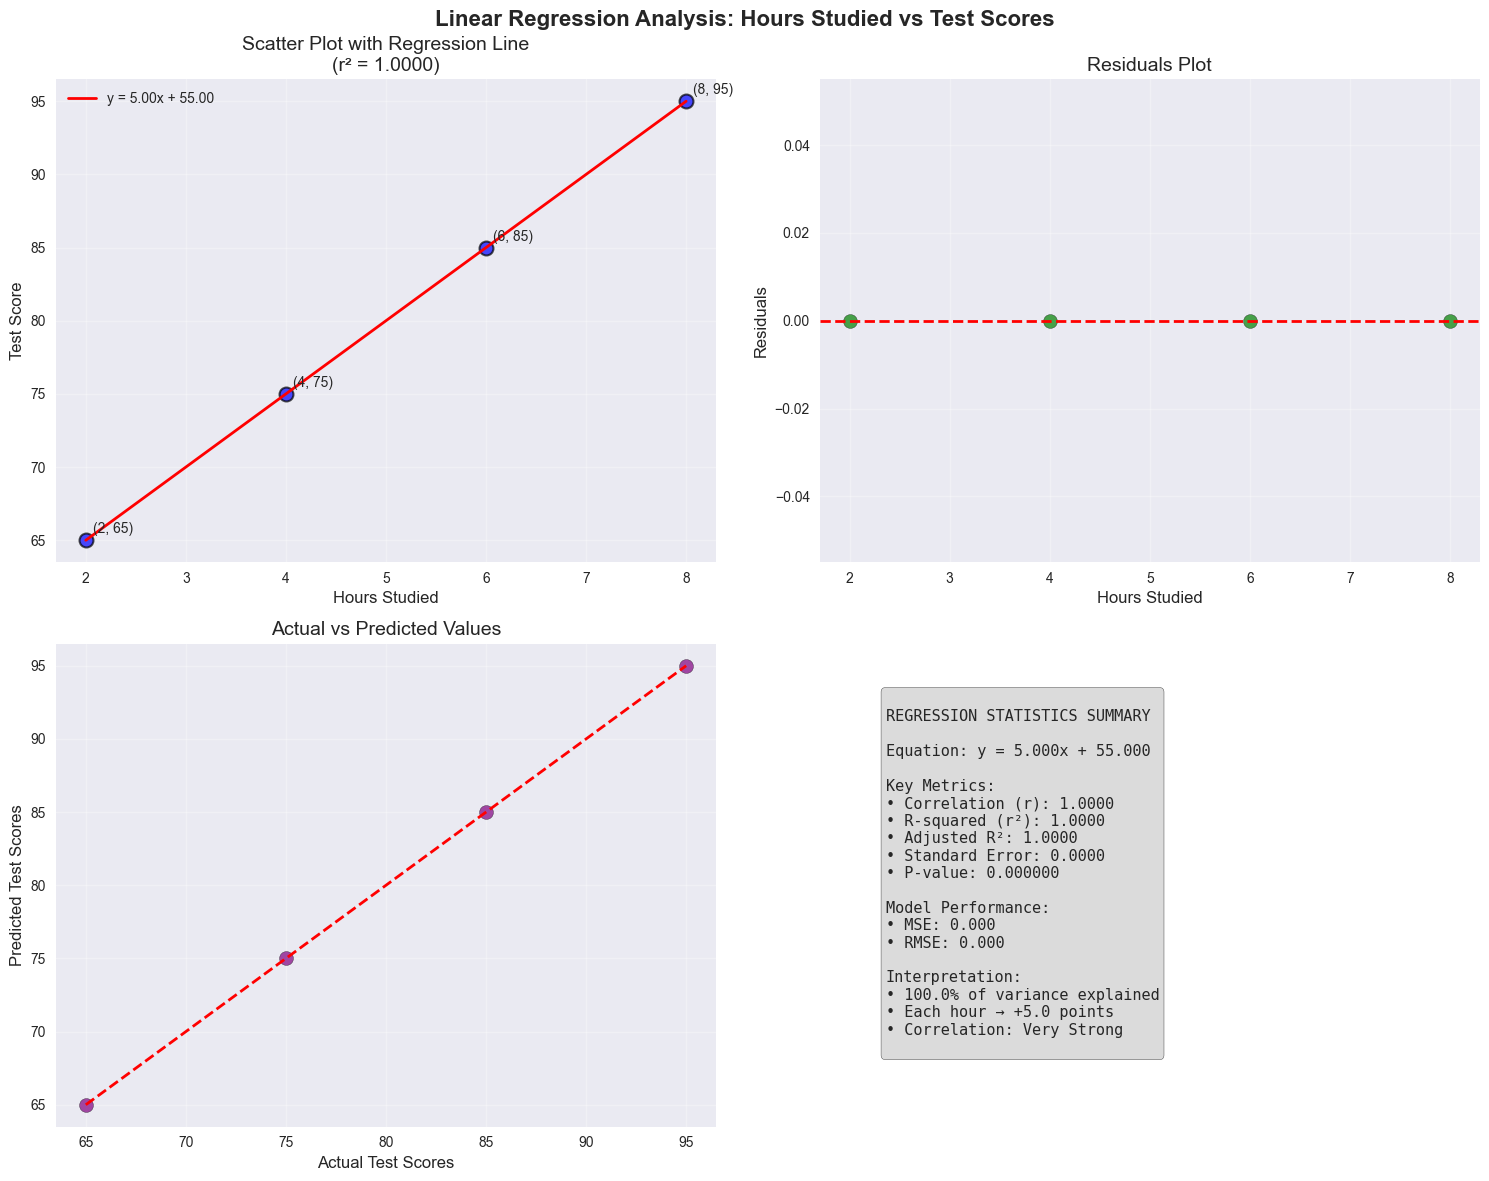

In [4]:
# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Linear Regression Analysis: Hours Studied vs Test Scores', fontsize=16, fontweight='bold')

# 1. Main scatter plot with regression line
ax1.scatter(hours_studied, test_scores, color='blue', s=100, alpha=0.7, edgecolor='black', linewidth=1.5)
x_line = np.linspace(hours_studied.min(), hours_studied.max(), 100)
y_line = slope * x_line + intercept
ax1.plot(x_line, y_line, 'r-', linewidth=2, label=f'y = {slope:.2f}x + {intercept:.2f}')
ax1.set_xlabel('Hours Studied', fontsize=12)
ax1.set_ylabel('Test Score', fontsize=12)
ax1.set_title(f'Scatter Plot with Regression Line\n(r² = {r_squared:.4f})', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add data point labels
for i, (x, y) in enumerate(zip(hours_studied, test_scores)):
    ax1.annotate(f'({x}, {y})', (x, y), xytext=(5, 5), textcoords='offset points', fontsize=10)

# 2. Residuals plot
ax2.scatter(hours_studied, residuals, color='green', s=100, alpha=0.7, edgecolor='black')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Hours Studied', fontsize=12)
ax2.set_ylabel('Residuals', fontsize=12)
ax2.set_title('Residuals Plot', fontsize=14)
ax2.grid(True, alpha=0.3)

# 3. Actual vs Predicted values
ax3.scatter(test_scores, predicted_scores, color='purple', s=100, alpha=0.7, edgecolor='black')
ax3.plot([test_scores.min(), test_scores.max()], [test_scores.min(), test_scores.max()], 'r--', linewidth=2)
ax3.set_xlabel('Actual Test Scores', fontsize=12)
ax3.set_ylabel('Predicted Test Scores', fontsize=12)
ax3.set_title('Actual vs Predicted Values', fontsize=14)
ax3.grid(True, alpha=0.3)

# 4. Statistics summary as text
ax4.axis('off')
stats_text = f"""
REGRESSION STATISTICS SUMMARY

Equation: y = {slope:.3f}x + {intercept:.3f}

Key Metrics:
• Correlation (r): {r_value:.4f}
• R-squared (r²): {r_squared:.4f}
• Adjusted R²: {1 - (1 - r_squared) * (n - 1) / degrees_freedom:.4f}
• Standard Error: {std_err:.4f}
• P-value: {p_value:.6f}

Model Performance:
• MSE: {mse:.3f}
• RMSE: {rmse:.3f}

Interpretation:
• {r_squared*100:.1f}% of variance explained
• Each hour → +{slope:.1f} points
• Correlation: {'Very Strong' if r_squared > 0.8 else 'Strong' if r_squared > 0.6 else 'Moderate'}
"""

ax4.text(0.1, 0.9, stats_text, transform=ax4.transAxes, fontsize=11, 
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

In [5]:
# Detailed statistical table
print("=== DETAILED STATISTICAL ANALYSIS ===\n")

# Create detailed results table
results_table = pd.DataFrame({
    'Hours_Studied': hours_studied,
    'Actual_Score': test_scores,
    'Predicted_Score': predicted_scores.round(2),
    'Residual': residuals.round(2),
    'Residual_Squared': (residuals ** 2).round(2)
})

print("Individual Data Points Analysis:")
print(results_table.to_string(index=False))

print(f"\n=== REGRESSION EQUATION ===")
print(f"Test Score = {slope:.3f} × Hours Studied + {intercept:.3f}")

print(f"\n=== STATISTICAL MEASURES ===")
stats_dict = {
    'Measure': ['Sample Size (n)', 'Degrees of Freedom', 'Slope (β₁)', 'Y-Intercept (β₀)', 
                'Correlation (r)', 'R-squared (r²)', 'Adjusted R²', 'Standard Error', 
                'P-value', 'MSE', 'RMSE', 'Sum of Squares Total', 'Sum of Squares Residual'],
    'Value': [n, degrees_freedom, slope, intercept, r_value, r_squared, 
              1 - (1 - r_squared) * (n - 1) / degrees_freedom, std_err, p_value,
              mse, rmse, np.sum((test_scores - np.mean(test_scores))**2),
              np.sum(residuals**2)]
}

stats_df = pd.DataFrame(stats_dict)
stats_df['Value'] = stats_df['Value'].round(6)
print(stats_df.to_string(index=False))

print(f"\n=== CONFIDENCE & PREDICTION ===")
print(f"• 95% Confidence Level: α = 0.05")
print(f"• Critical t-value (df={degrees_freedom}): ±{stats.t.ppf(0.975, degrees_freedom):.3f}")
print(f"• If p < 0.05, relationship is statistically significant")
print(f"• Current p-value: {p_value:.6f} → {'Significant' if p_value < 0.05 else 'Not Significant'}")

=== DETAILED STATISTICAL ANALYSIS ===

Individual Data Points Analysis:
 Hours_Studied  Actual_Score  Predicted_Score  Residual  Residual_Squared
             2            65             65.0       0.0               0.0
             4            75             75.0       0.0               0.0
             6            85             85.0       0.0               0.0
             8            95             95.0       0.0               0.0

=== REGRESSION EQUATION ===
Test Score = 5.000 × Hours Studied + 55.000

=== STATISTICAL MEASURES ===
                Measure  Value
        Sample Size (n)    4.0
     Degrees of Freedom    2.0
             Slope (β₁)    5.0
       Y-Intercept (β₀)   55.0
        Correlation (r)    1.0
         R-squared (r²)    1.0
            Adjusted R²    1.0
         Standard Error    0.0
                P-value    0.0
                    MSE    0.0
                   RMSE    0.0
   Sum of Squares Total  500.0
Sum of Squares Residual    0.0

=== CONFIDENCE & PRE